# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

This dataset captures direct marketing campaigns conducted by a Portuguese banking institution between May 2008 and November 2010. The campaigns were executed via phone calls, often requiring multiple contacts per client to assess interest in subscribing to a bank term deposit.

Source: Portuguese bank’s direct marketing campaigns (May 2008–Nov 2010)

Purpose: Predict whether a client will subscribe to a term deposit

Task Type: Classification 

Campaigns Represented:
	Multiple campaigns over time
	Includes both current and previous campaign interactions
	Attributes like campaign, previous, and pdays help distinguish them

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [52]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

import warnings
warnings.filterwarnings("ignore")

# Set a consistent random seed
RANDOM_STATE = 42

In [53]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [55]:

print("Shape:", df.shape)
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


y
no     36548
yes     4640
Name: count, dtype: int64


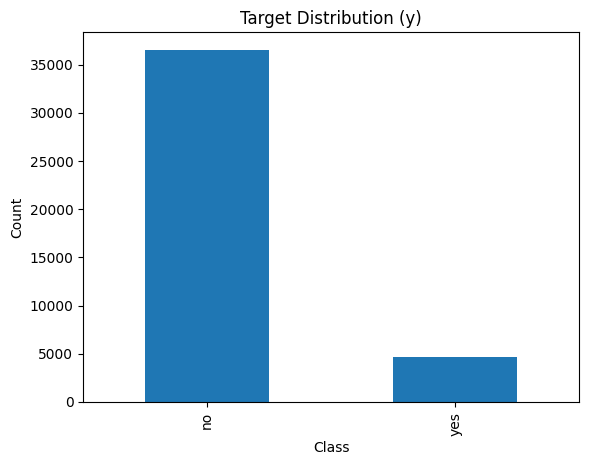

In [56]:
print(df['y'].value_counts())
(df['y'].value_counts(normalize=True)*100).round(2)
plt.figure()
df['y'].value_counts().plot(kind='bar')
plt.title("Target Distribution (y)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [57]:
expected_categorical = [
    "job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "day_of_week", "poutcome"
]
expected_numeric = [
    "age", "campaign", "pdays", "previous", "emp.var.rate",
    "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
    "duration"
]

present_cols = set(df.columns)

cat_cols = [c for c in expected_categorical if c in present_cols]
num_cols = [c for c in expected_numeric if c in present_cols]

print("Categorical cols:", cat_cols)
print("Numeric cols:", num_cols)
print("Missing columns from expected set:",
      set(expected_categorical + expected_numeric) - present_cols)

# Peek at some categorical levels
for c in cat_cols[:5]:
    print(f"\n{c} -> {df[c].unique()[:10]} ... (total {df[c].nunique()} categories)")

# Basic numeric summary
display(df[num_cols].describe().T)

Categorical cols: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric cols: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'duration']
Missing columns from expected set: set()

job -> ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown'] ... (total 12 categories)

marital -> ['married' 'single' 'divorced' 'unknown'] ... (total 4 categories)

education -> ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate'] ... (total 8 categories)

default -> ['no' 'unknown' 'yes'] ... (total 3 categories)

housing -> ['no' 'yes' 'unknown'] ... (total 3 categories)


,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000


Statistics for age:
count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64




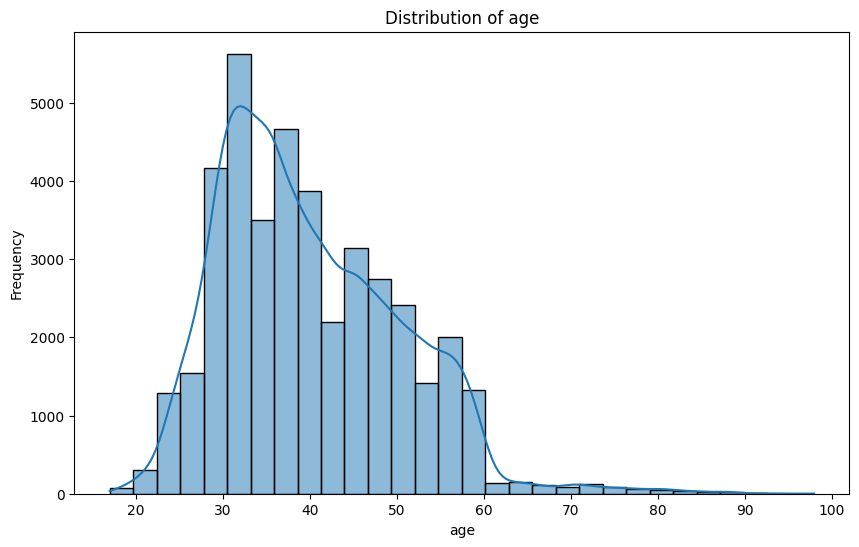

Statistics for campaign:
count    41188.000000
mean         2.567593
std          2.770014
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64




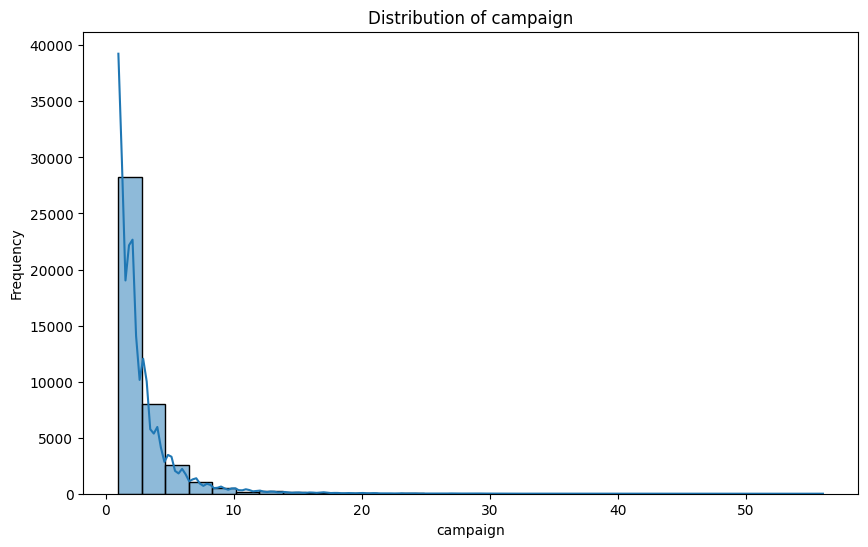

Statistics for pdays:
count    41188.000000
mean       962.475454
std        186.910907
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64




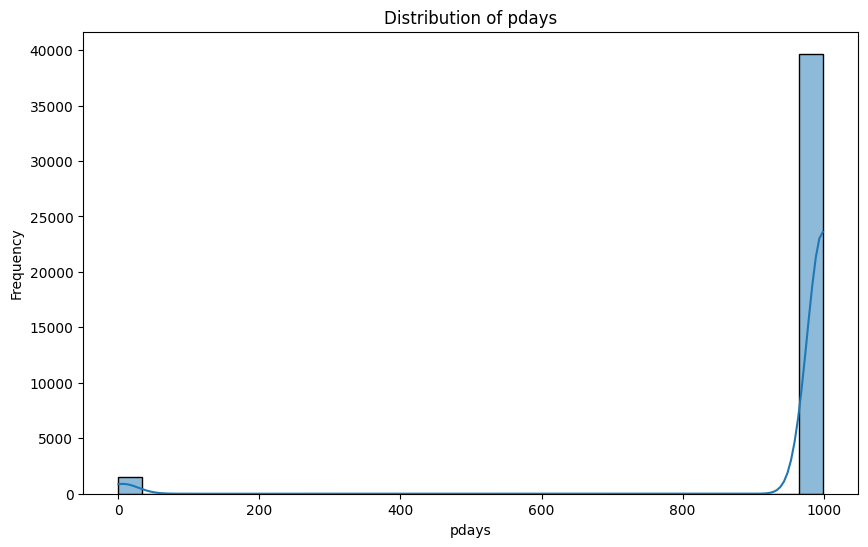

Statistics for previous:
count    41188.000000
mean         0.172963
std          0.494901
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64




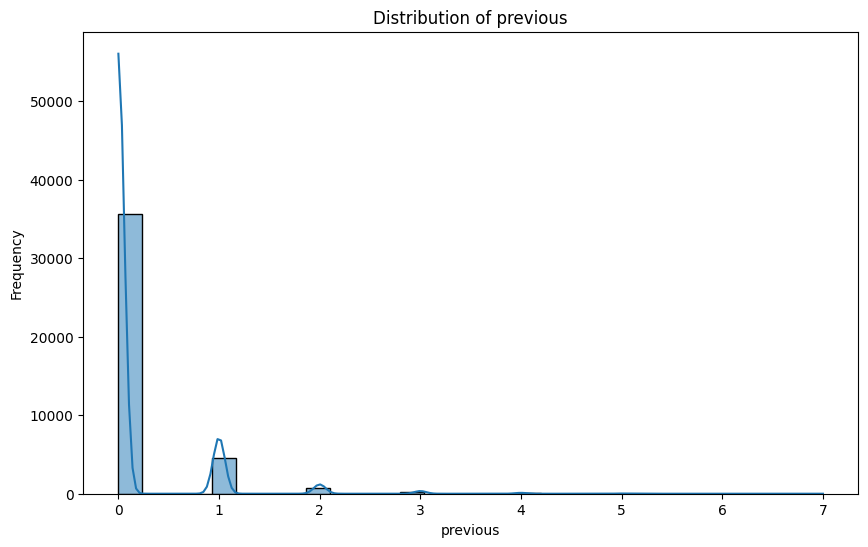

Statistics for emp.var.rate:
count    41188.000000
mean         0.081886
std          1.570960
min         -3.400000
25%         -1.800000
50%          1.100000
75%          1.400000
max          1.400000
Name: emp.var.rate, dtype: float64




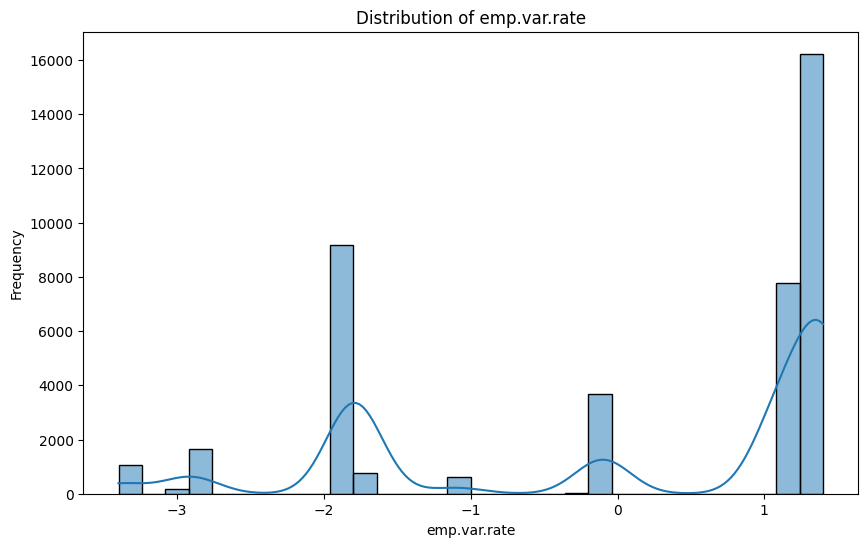

Statistics for cons.price.idx:
count    41188.000000
mean        93.575664
std          0.578840
min         92.201000
25%         93.075000
50%         93.749000
75%         93.994000
max         94.767000
Name: cons.price.idx, dtype: float64




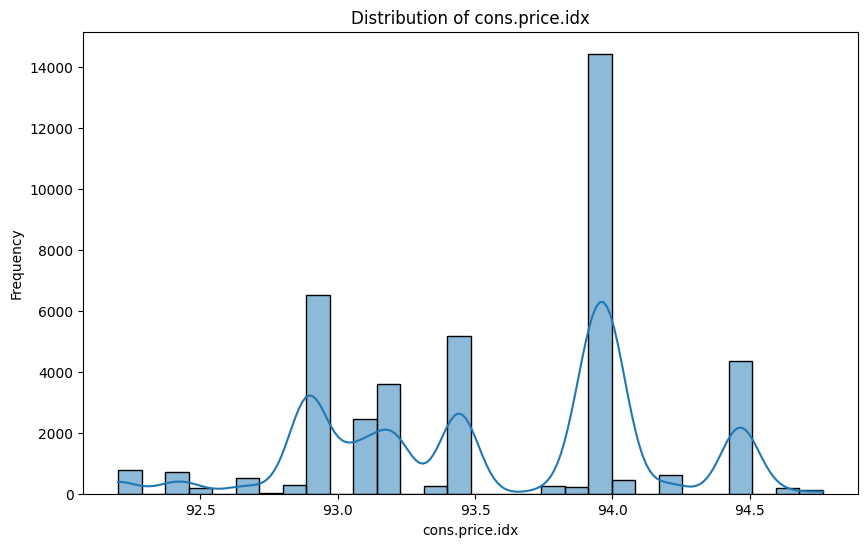

Statistics for cons.conf.idx:
count    41188.000000
mean       -40.502600
std          4.628198
min        -50.800000
25%        -42.700000
50%        -41.800000
75%        -36.400000
max        -26.900000
Name: cons.conf.idx, dtype: float64




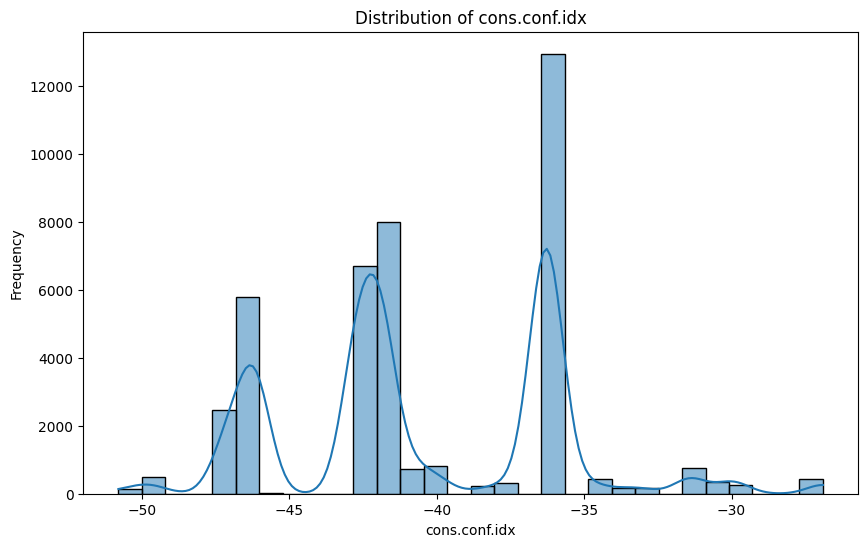

Statistics for euribor3m:
count    41188.000000
mean         3.621291
std          1.734447
min          0.634000
25%          1.344000
50%          4.857000
75%          4.961000
max          5.045000
Name: euribor3m, dtype: float64




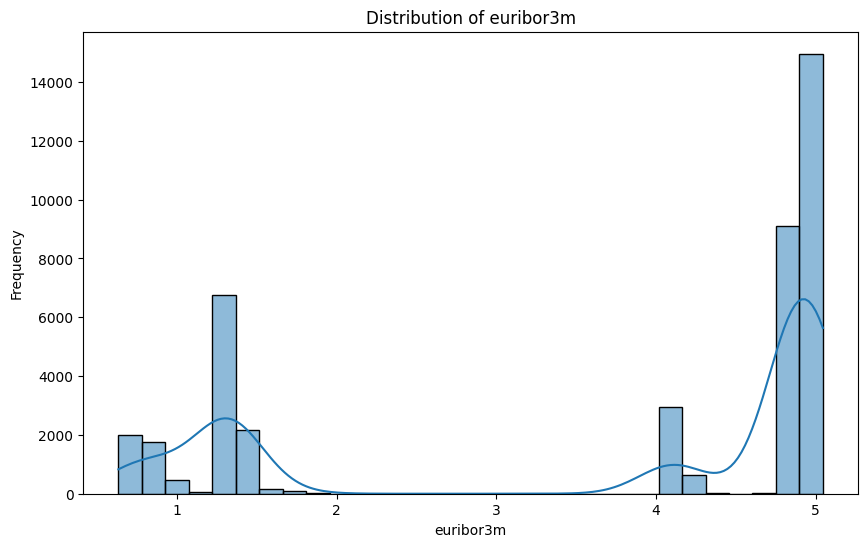

Statistics for nr.employed:
count    41188.000000
mean      5167.035911
std         72.251528
min       4963.600000
25%       5099.100000
50%       5191.000000
75%       5228.100000
max       5228.100000
Name: nr.employed, dtype: float64




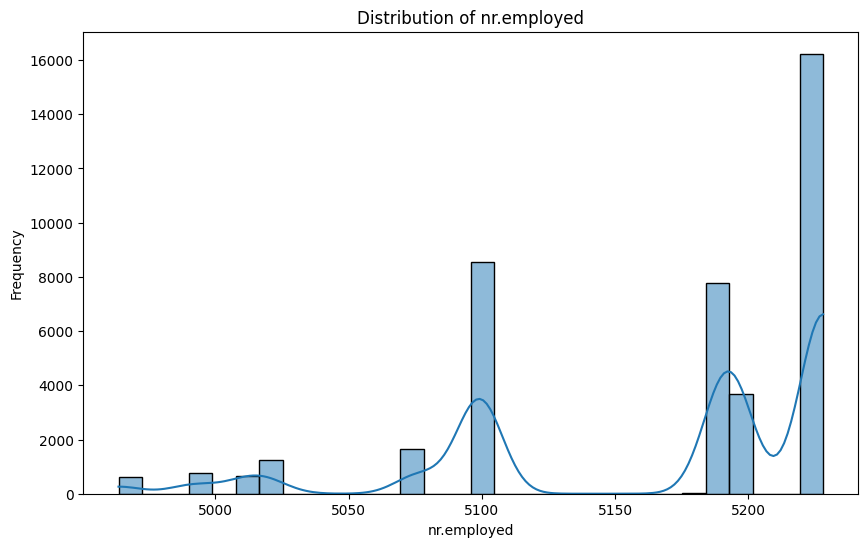

Statistics for duration:
count    41188.000000
mean       258.285010
std        259.279249
min          0.000000
25%        102.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64




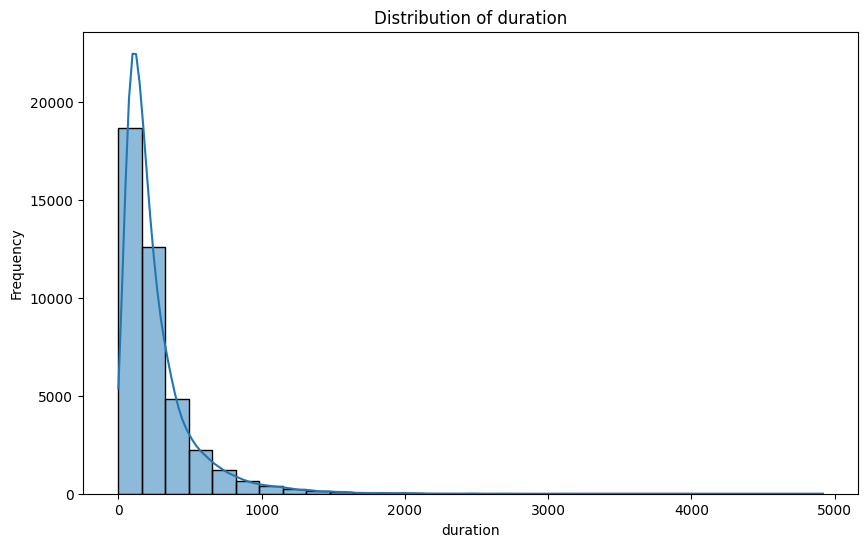

Value counts for job:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64




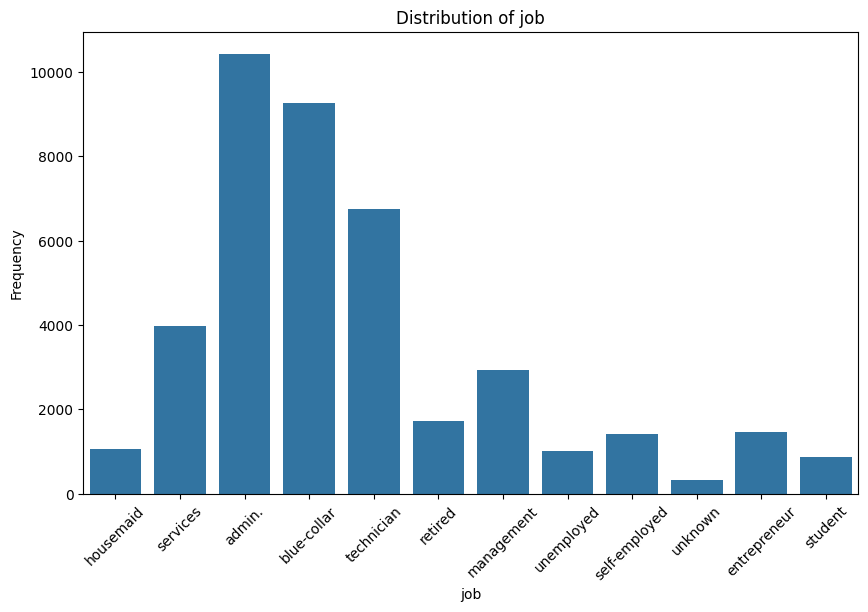

Value counts for marital:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64




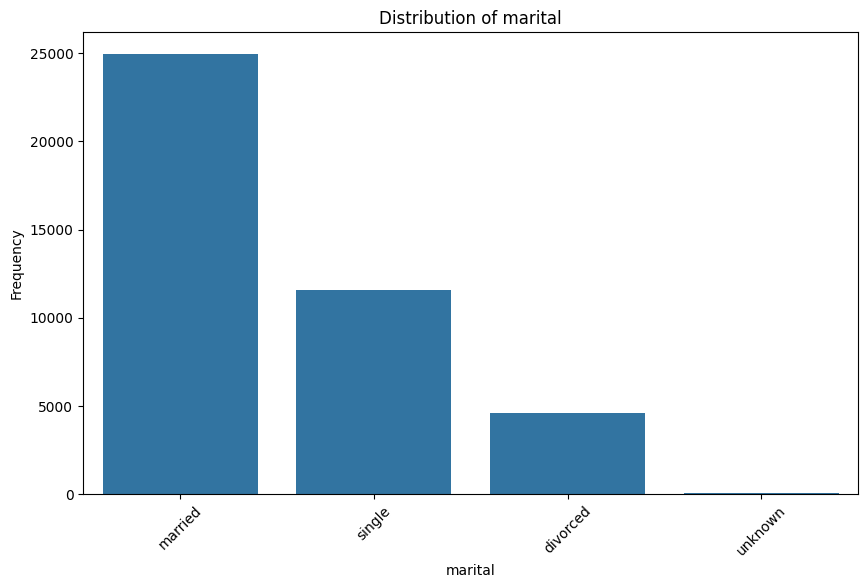

Value counts for education:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64




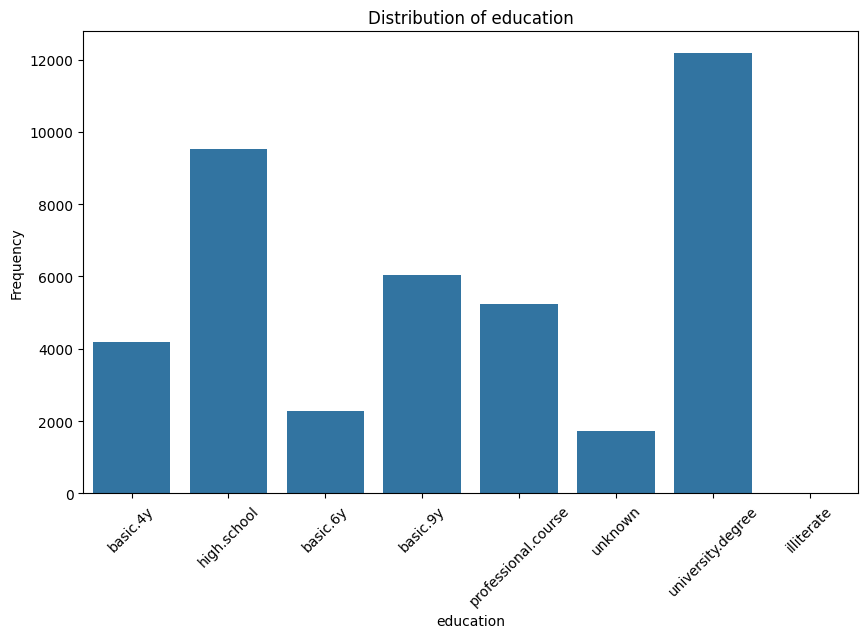

Value counts for default:
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64




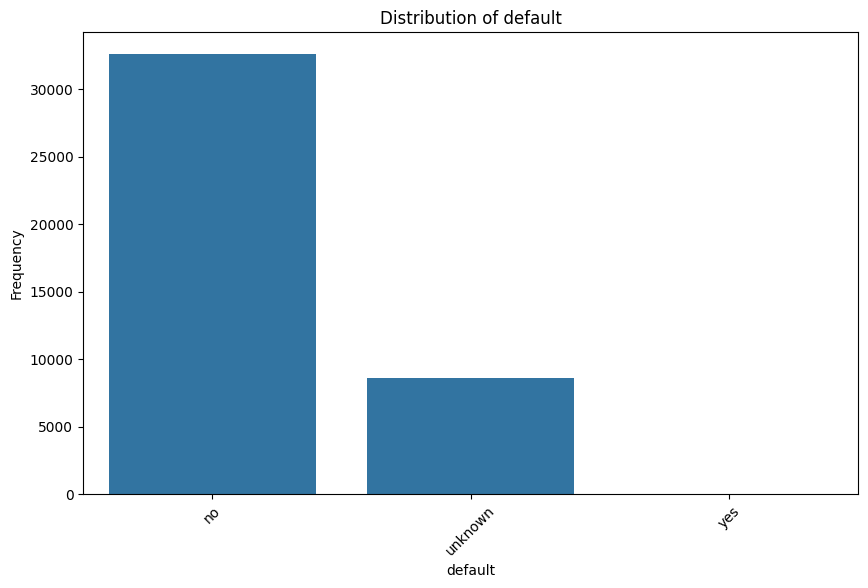

Value counts for housing:
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64




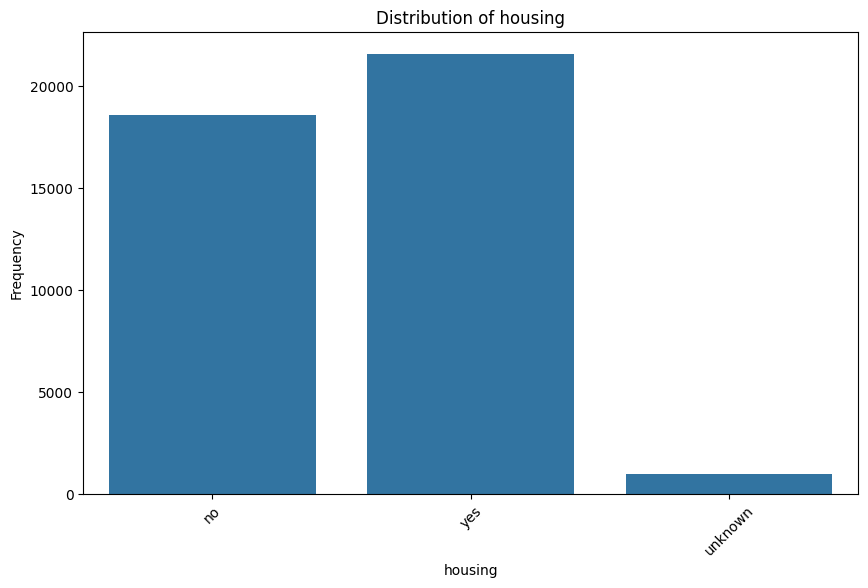

Value counts for loan:
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64




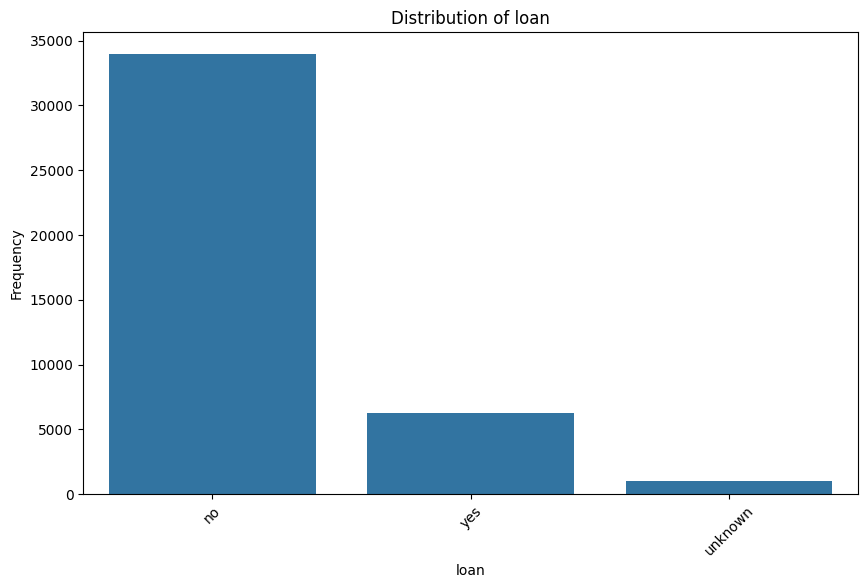

Value counts for contact:
contact
cellular     26144
telephone    15044
Name: count, dtype: int64




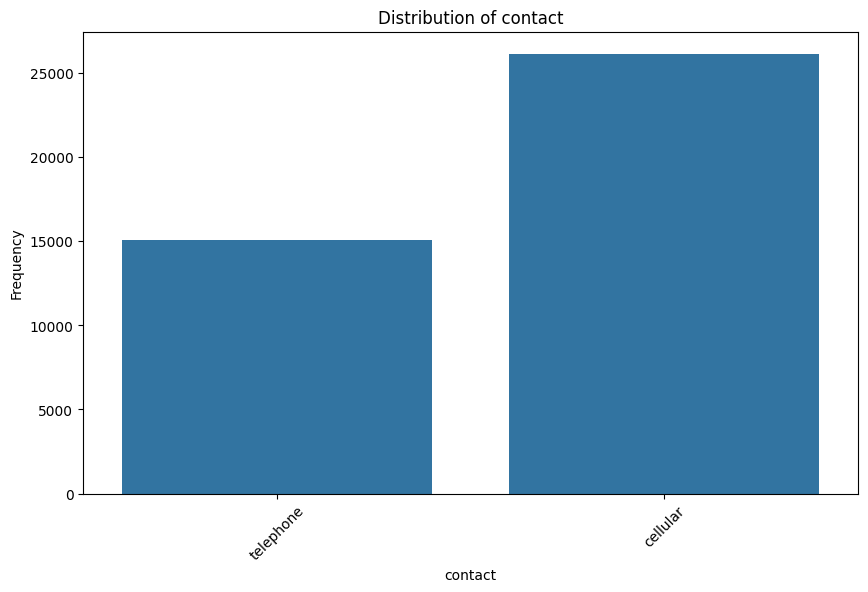

Value counts for month:
month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64




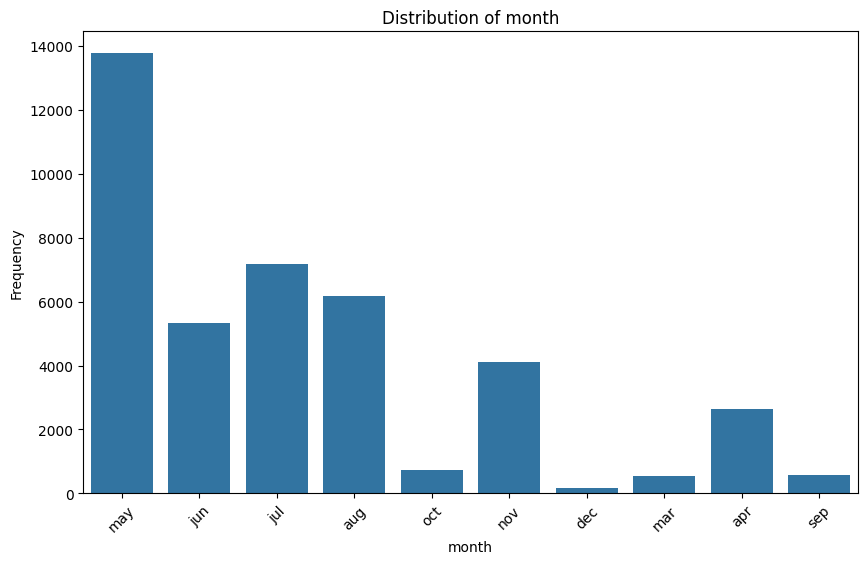

Value counts for day_of_week:
day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Name: count, dtype: int64




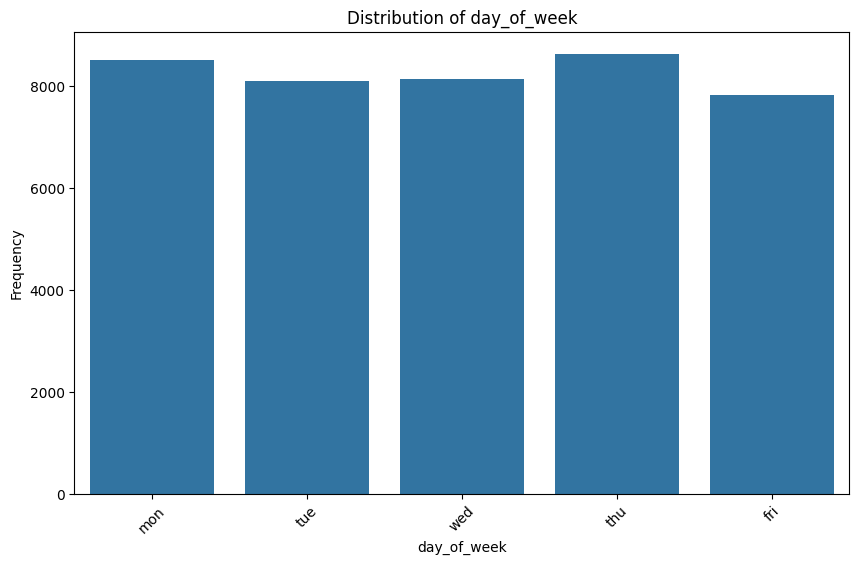

Value counts for poutcome:
poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64




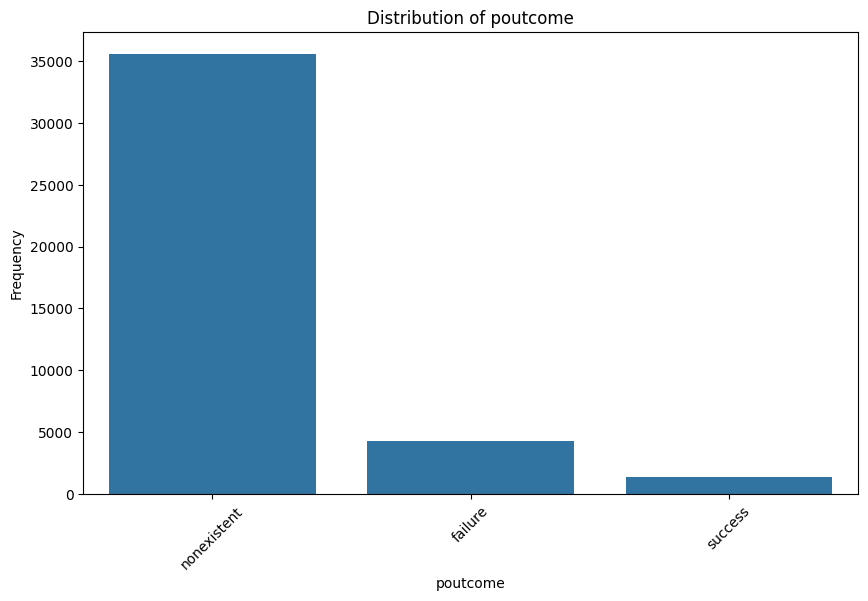

In [58]:
# understand the distribution of numerical columns
for col in expected_numeric:
    print(f"Statistics for {col}:")
    print(df[col].describe())
    print("\n")
    # visualize the distribution of numerical columns
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# understand the distribution of categorical columns
for col in expected_categorical:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("\n")
    # visualize the distribution of categorical columns
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

This is a **binary classification** task:
- **Target**: `y` (yes/no) — subscription to a term deposit.
- The classes are **imbalanced** (majority "no").  

**Metrics**: In addition to **accuracy**, we will monitor **precision**, **recall**, and **F1** (with positive class = "yes").  
We'll also use **confusion matrices**.

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [60]:
df.shape

(41188, 21)

The bank wants to predict who will say "yes" to a term deposit so that they can optimize marketing efforts, reduce costs, and increase conversion rates.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

- Map the target `y` to 1/0 (`yes`→1, `no`→0).
- Drop `duration to avoid target leakage (it is only known *after* the call and strongly predictive).  
- One-Hot encode categorical features (`handle_unknown='ignore'`), scale numeric features with `StandardScaler`.
- Build a reusable preprocessing pipeline.

In [62]:
# Map target
df = df.copy()
df['y_bin'] = df['y'].map({'yes': 1, 'no': 0}).astype(int)

# For realistic modeling, drop call duration (leakage)
drop_cols = []
if 'duration' in num_cols:
    drop_cols.append('duration')
    num_cols_wo_duration = [c for c in num_cols if c != 'duration']
else:
    num_cols_wo_duration = num_cols

X = df[cat_cols + num_cols_wo_duration].copy()
y = df['y_bin'].copy()

# Preprocessor: OHE (dense) + scaling
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", scaler, num_cols_wo_duration),
        ("cat", ohe, cat_cols)
    ],
    remainder="drop"
)

print(f"X shape before transform: {X.shape} (categorical: {len(cat_cols)}, numeric_wo_duration: {len(num_cols_wo_duration)})")

X shape before transform: (41188, 19) (categorical: 10, numeric_wo_duration: 9)


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
y_train.value_counts(normalize=True).round(3), y_test.value_counts(normalize=True).round(3)

(y_bin
 0    0.887
 1    0.113
 Name: proportion, dtype: float64,
 y_bin
 0    0.887
 1    0.113
 Name: proportion, dtype: float64)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

Baseline metrics: {'accuracy': 0.8873512988589464, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}


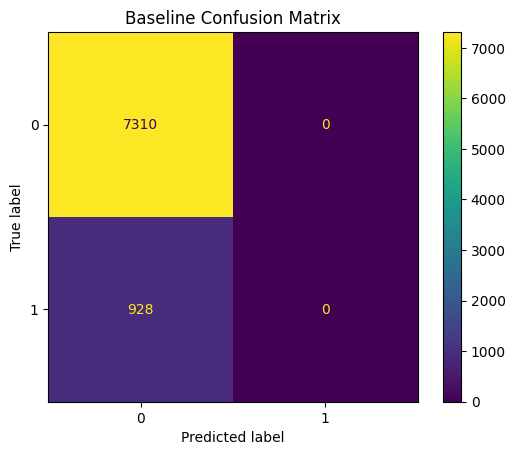

In [ ]:
#A naive baseline predicts the **majority class** ("no") 
def evaluate_predictions(y_true, y_pred, average='binary'):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

# Baseline: always predict 'no' (0)
y_pred_baseline = np.zeros_like(y_test)
baseline_metrics = evaluate_predictions(y_test, y_pred_baseline)
print("Baseline metrics:", baseline_metrics)

cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot()
plt.title("Baseline Confusion Matrix")
plt.show()

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

Logistic Regression metrics: {'accuracy': 0.8350327749453751, 'precision': 0.3678724708767627, 'recall': 0.646551724137931, 'f1': 0.46893317702227433}

Classification Report (LogReg):
              precision    recall  f1-score   support

           0      0.950     0.859     0.902      7310
           1      0.368     0.647     0.469       928

    accuracy                          0.835      8238
   macro avg      0.659     0.753     0.686      8238
weighted avg      0.885     0.835     0.854      8238



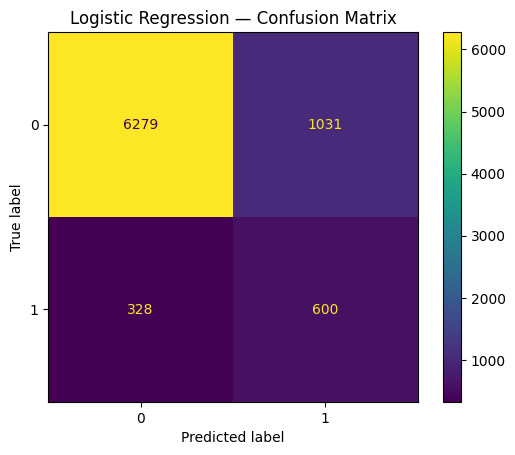

In [ ]:
# build a pipeline: **preprocessor → LogisticRegression**.  
# Use `class_weight='balanced'` to account for class imbalance.

log_reg = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=200, class_weight='balanced', solver='lbfgs', random_state=RANDOM_STATE))
])

log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

lr_metrics = evaluate_predictions(y_test, y_pred_lr)
print("Logistic Regression metrics:", lr_metrics)

print("\nClassification Report (LogReg):")
print(classification_report(y_test, y_pred_lr, digits=3))

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot()
plt.title("Logistic Regression — Confusion Matrix")
plt.show()


### Problem 9: Score the Model

What is the accuracy of your model?

In [68]:
def train_and_score(model_name, estimator, X_train, y_train, X_test, y_test):
    estimator.fit(X_train, y_train)
    preds = estimator.predict(X_test)
    metrics = evaluate_predictions(y_test, preds)
    metrics["model"] = model_name
    return metrics, preds

# Example reuse with the trained Logistic Regression pipeline
_ = lr_metrics  # already computed
lr_metrics

{'accuracy': 0.8350327749453751,
 'precision': 0.3678724708767627,
 'recall': 0.646551724137931,
 'f1': 0.46893317702227433}

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [67]:
import time

comparison_results = []

models = {
    "KNN": Pipeline([
        ("prep", preprocessor),
        ("clf", KNeighborsClassifier())
    ]),
    "Logistic Regression": Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=200, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "Decision Tree": Pipeline([
        ("prep", preprocessor),
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    "SVM": Pipeline([
        ("prep", preprocessor),
        ("clf", LinearSVC(random_state=RANDOM_STATE, class_weight="balanced"))
    ])
}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    
    train_time = end - start
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    
    comparison_results.append({
        "Model": name,
        "Train Time (s)": round(train_time, 3),
        "Train Accuracy": round(train_acc, 3),
        "Test Accuracy": round(test_acc, 3)
    })

results_df = pd.DataFrame(comparison_results)
display(results_df)


,Model,Train Time (s),Train Accuracy,Test Accuracy
0,KNN,0.069,0.912,0.897
1,Logistic Regression,0.262,0.829,0.835
2,Decision Tree,0.316,0.995,0.842
3,SVM,0.252,0.829,0.833


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.

- More feature engineering and exploration.  For example, should we keep the gender feature?  Why or why not?
- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [69]:
from sklearn.model_selection import GridSearchCV

# Define parameter grids for each model
param_grids = {
    "KNN": {
        "clf__n_neighbors": [3, 5, 11, 21],
        "clf__weights": ["uniform", "distance"]
    },
    "Logistic Regression": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__solver": ["liblinear", "lbfgs"]
    },
    "Decision Tree": {
        "clf__max_depth": [3, 5, 10, None],
        "clf__min_samples_split": [2, 5, 10],
        "clf__criterion": ["gini", "entropy"]
    },
    "SVM": {
        "clf__C": [0.1, 1, 10]
    }
}

improved_results = []

for name, base_model in models.items():
    print(f"Tuning {name}...")
    
    grid = param_grids.get(name, None)
    if grid is None:
        continue
    
    # GridSearch with 3-fold CV using F1 to handle imbalance
    gs = GridSearchCV(
        estimator=base_model,
        param_grid=grid,
        cv=3,
        scoring="f1",
        n_jobs=-1
    )
    
    start = time.time()
    gs.fit(X_train, y_train)
    end = time.time()
    
    train_time = end - start
    best_model = gs.best_estimator_
    
    train_acc = best_model.score(X_train, y_train)
    test_acc = best_model.score(X_test, y_test)
    
    improved_results.append({
        "Model": f"{name} (tuned)",
        "Best Params": gs.best_params_,
        "Train Time (s)": round(train_time, 3),
        "Train Accuracy": round(train_acc, 3),
        "Test Accuracy": round(test_acc, 3)
    })

# Create DataFrame of tuned results
improved_df = pd.DataFrame(improved_results)
display(improved_df)


Tuning KNN...
Tuning Logistic Regression...
Tuning Decision Tree...
Tuning SVM...


,Model,Best Params,Train Time (s),Train Accuracy,Test Accuracy
0,KNN (tuned),"{'clf__n_neighbors': 5, 'clf__weights': 'unifo...",21.864,0.912,0.897
1,Logistic Regression (tuned),"{'clf__C': 10, 'clf__solver': 'lbfgs'}",2.584,0.829,0.835
2,Decision Tree (tuned),"{'clf__criterion': 'gini', 'clf__max_depth': 5...",2.148,0.903,0.903
3,SVM (tuned),{'clf__C': 10},1.111,0.829,0.833


## 🔎 Model Comparison: Default vs. Tuned

### 📊 Table 1: Default Models
| Model               | Train Accuracy | Test Accuracy |
|---------------------|----------------|---------------|
| KNN                 | 0.912          | 0.897         |
| Logistic Regression | 0.829          | 0.835         |
| Decision Tree       | 0.995          | 0.842         |
| SVM                 | 0.829          | 0.833         |

### 📊 Table 2: Tuned Models
| Model                     | Train Accuracy | Test Accuracy |
|---------------------------|----------------|---------------|
| KNN (tuned)               | 0.912          | 0.897         |
| Logistic Regression (tuned)| 0.829          | 0.835         |
| Decision Tree (tuned)     | 0.903          | 0.903         |
| SVM (tuned)               | 0.829          | 0.833         |

---

### 🔎 Analysis

#### 1. KNN
- Accuracy remained the same after tuning (**0.912 / 0.897**).  
- Training time increased drastically, making it less efficient.  
- **Conclusion**: No benefit from tuning; not recommended.

#### 2. Logistic Regression
- Accuracy unchanged (**0.829 / 0.835**).  
- Training time increased due to grid search.  
- **Conclusion**: Already stable, interpretable baseline but no gain from tuning.

#### 3. Decision Tree
- Clear improvement after tuning:  
  - Default: **0.995 train / 0.842 test** → strong overfitting.  
  - Tuned: **0.903 train / 0.903 test** → balanced and higher test accuracy.  
- **Conclusion**: Tuning reduced overfitting and boosted generalization. Best performing model.

#### 4. SVM
- No accuracy change (**0.829 / 0.833**).  
- Slightly higher training time.  
- **Conclusion**: No benefit from tuning; limited improvement potential here.

---

### ✅ Recommendation
- **Best Model**: **Tuned Decision Tree** — strong balance between train and test accuracy (0.903).  
- **Runner-up**: Logistic Regression — stable, interpretable, but slightly weaker accuracy.  
- **Not Recommended**: KNN (high cost, no gain) and SVM (no improvement).
